# Full example

## Let's bring it all together

Now, let us try to bring it all together to fully see what we can do with all of this together.
For this let us:

1. Get a list of Wikipedia articles about politicians and for each article the number of unique editors, the gender classification and the 'quality rating'
2. For each contributor to those articles: Get the number of politician pages they contributed to that are male/female and calculate a "specialisation" score (ratio of male/female articles edited)
3. For each politician article: sum over all specialisation scores for the editors, and plot against # of editors overall and ['quality rating'](https://en.wikipedia.org/wiki/Wikipedia:Content_assessment)

## Getting the articles

As we have seen before, there are around 1,000 Wikidata entries about Kenyan politicians.
To keep things manageable for our test. Let's start with a smaller number, and let's also again try to get a more balanced sample of pages with respect to gender.

### Some initial setup

Let's load our libraries and prepare some functions we'll be using to get this data:

In [229]:
import pywikibot # loading the pywikibot library
from pywikibot import pagegenerators as pg # import the page generator so we can iterate over all returned Wikidata items

import pandas as pd # loading pandas for data manipulation

WIKIPEDIA_SITE = pywikibot.Site("en", 'wikipedia') # creating an English WP site object to get page details

WIKIDATA_SITE = pywikibot.Site("wikidata", 'wikidata')


def get_gender(wikidata_item):
    '''
    Look at the property for gendre and return the
    english language gender label if present. If not,
    return "unknown" - useful when our queries do not
    presume the response
    '''
    if "P21" in wikidata_item.claims.keys():
        return wikidata_item.claims['P21'][0].target.labels['en']
    else:
        return "unknown"


def get_content_assessment(p):
    '''
    Takes a regular page object to first get the 
    associated talk page (assessments are on those)
    and then return the assessment found.
    '''
    assessment = ["FA", "FL", "FM", "A", "GA", "B", "C", "Start", "Stub"]
    tpage = p.toggleTalkPage()
    for c in tpage.categories(): # iterate over all categories
        for a in assessment: # iterate over possible asssements
            if c.title().startswith("Category:{}-Class".format(a)):
                return a # found assessment category and return  
    return None # if none found, return None

def run_query(QUERY):
    '''
    Run's the handed query and returns a dictionary that contains
    the following information, for politicians that have an article
    in the English language wikipedia
    1. Item ID in wikidata
    2. name of Wikipedia page
    3. gender of politician
    4. number of unique editors
    5. quality rating
    '''
    generator = pg.WikidataSPARQLPageGenerator(QUERY, site=WIKIDATA_SITE)

    politician_data = {}

    for item in generator:
        qid = item.getID() # get unique ID
        # check that has english language article:
        if 'enwiki' in item.sitelinks.keys():
            page_title = item.sitelinks['enwiki'].canonical_title()
            page = pywikibot.Page(WIKIPEDIA_SITE, page_title)

            politician_data[qid] = {} # initialize dictionary 
            politician_data[qid]['gender'] = get_gender(item) # add gender
            politician_data[qid]['name'] = page_title # add english article name
            politician_data[qid]['content_assessment'] = get_content_assessment(page)
            contributors = list(page.contributors())
            politician_data[qid]['contributor_count'] = len(contributors)
            politician_data[qid]['contributor_list'] = contributors
    return politician_data

### Writing our queries and executing them

For testing purposes and not waiting for a long time for the API, Let's now get 50 articles each for male and female politicians to get us started:

(**note: currently the outputs below use *all* articles!**)

In [230]:
male_query = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
          wdt:P21 wd:Q6581097; # male
}
LIMIT 1200
"""

female_query = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
          wdt:P21 wd:Q6581072; # female
}
LIMIT 1200
"""

page_data_male = run_query(male_query)
page_data_female = run_query(female_query)

Now that we got our two dictionaries, we can merge them into a data frame as we've done before:

In [231]:
all_page_data = page_data_male | page_data_female
df_all_page_data = pd.DataFrame(all_page_data).T
df_all_page_data

,gender,name,content_assessment,contributor_count,contributor_list
Q19664415,male,Humphrey Slade,C,28,"[PrimeBOT, Staryu, Dodszi gera, Dgp4004, Jevan..."
Q6268381,male,Johnson Muthama,Stub,90,"[TejasTann, JemimaV, ThePageFixer, Tgyatso, Ab..."
Q5482591,male,Francis Thombe Nyammo,Stub,22,"[Zackmann08, Robby.is.on, 68.6.135.88, Mohamad..."
Q593552,male,Michael Kijana Wamalwa,C,94,"[JemimaV, Zackmann08, SuperCode111, ~2025-3133..."
Q4680594,male,Adan Keynan Wehliye,Start,93,"[Explicit, Zackmann08, Masohpotato, DualeKenya..."
...,...,...,...,...,...
Q47531099,female,Monica Juma,Start,81,"[Briianbraiin, Tescoid, JJMC89 bot III, Editor..."
Q7071124,female,Nyiva Mwendwa,Start,37,"[PrimeBOT, JemimaV, Asamoah Daniel Kwame Oware..."
Q21062983,female,Marianne Jebet Kitany,Start,37,"[JemimaV, Zackmann08, Masohpotato, TheMDC4, K-..."
Q47490080,female,Lilian Tomitom,Stub,4,"[Simeon, GrahamHardy, Bamyers99, Pi]"


Let's look at the gender breakdown of our sample now:

In [256]:
df_all_page_data.groupby(['gender'])['name'].count()

gender
female    153
male      493
Name: name, dtype: int64

So we end up with ~3x as many male articles as female articles.

Now we got the data frame with the information we want for each article so far, along with the list of contributors.

## Classifying contributros

This allows us to now aggregate the information about the contributors and how many male/female biographies they have contributed to. For this, we iterate over all the rows we have and count how many female or male articles they have contributed to:

In [232]:
from collections import defaultdict

# the default value for our dictionary is a sub-dictionary
# this makes it easier to create a dictionary of dictionaries
# in this form:
# {'editor_name': {
#    'male': 10, 
#    'female': 15},
#  'editor_2': {
#    'male': 1, 
#    'female': 4},
#}

editors = defaultdict(dict)

for index, row in df_all_page_data.iterrows():
    for contributor in row['contributor_list']:
        if row['gender'] in editors[contributor].keys():
            editors[contributor][row['gender']] += 1
        else:
            editors[contributor][row['gender']] = 1

# let's convert it into a DF as well
df_editors = pd.DataFrame(editors).T
df_editors

,male,female
PrimeBOT,164.0,47.0
Staryu,3.0,3.0
Dodszi gera,1.0,NaN
Dgp4004,17.0,2.0
Jevansen,72.0,55.0
...,...,...
Enos733,NaN,1.0
102.69.224.26,NaN,1.0
85.115.58.180,NaN,1.0
2A02:C7D:B8FB:F900:401F:D8DF:484:6AF0,NaN,1.0


As we can see, some of those values wil be `NaN` (*not a number*) as the editors haven't contributed to one of the two categories. In reality, those missing bits are `0`, so let's replace those:

In [233]:
df_editors = df_editors.fillna(0)

Now we can count the total number of pages the users edited (that is, pages in our sample, not the total pages they ever edited!) and then get the fraction of edits that went to male edits:

In [234]:
df_editors['total_pages'] = df_editors['male'] + df_editors['female']
df_editors['percent_male'] = df_editors['male'] /  df_editors['total_pages']  

<Axes: ylabel='Frequency'>

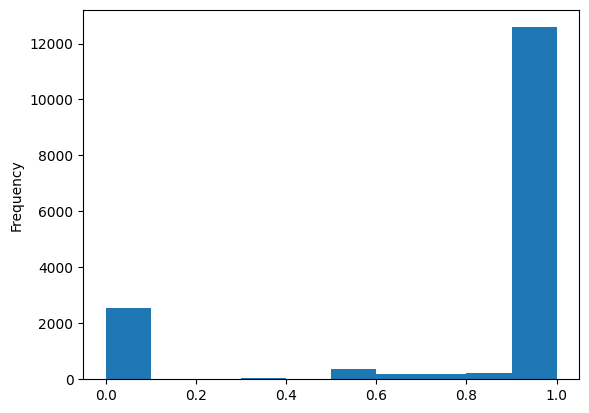

In [235]:
df_editors['percent_male'].plot(kind='hist')

That looks very strongly bi-modal. But this could be an artifact, if we remember participation inequality in Wikipedia: The vast majority of users here will have likely only done a single edit, which by definition would end up in either in the 0% or 100% group. Let's plot that number of edited pages to explore this:

<Axes: ylabel='Frequency'>

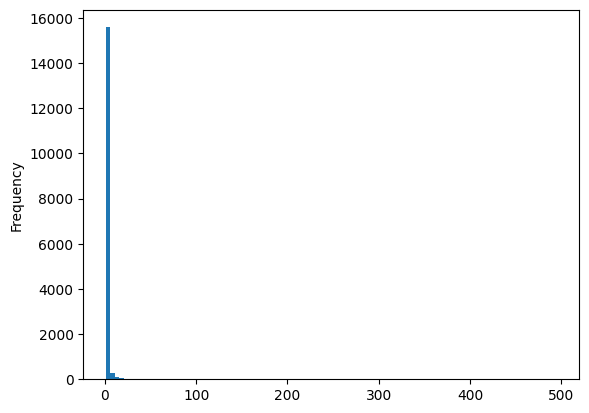

In [236]:
df_editors['total_pages'].plot(kind='hist',bins=100)

As expected, we see that the overwhemling majority of all 8000 editors only touched a single page, heavily biasing our results. Let's require people to have at least edited 2 pages to avoid this and remove the outliers:

<Axes: ylabel='Frequency'>

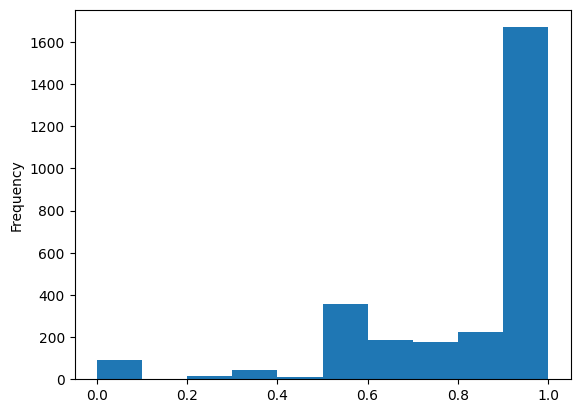

In [237]:
df_editors[df_editors['total_pages']>=2]['percent_male'].plot(kind='hist')

## Classify articles by mean specialisation score

While we still see a strong male-bias, this removes the large outliers that were purely a statistical artifact. We can now use those editor classifications to calculate the 'specialisation' score:

In [238]:
def calculate_specialisation_score(row,df_editors):
    '''
    give average "specialisation" score
    for all contributors who touched article
    and edited 2+ articles in set
    '''
    score = 0
    contribs = 0
    for contributor in row['contributor_list']:
        if contributor in df_editors.index:
            score += float(
                df_editors.loc[[contributor]]['percent_male'].iloc[0]
            )
            contribs += 1
    if contribs:
        return score / contribs
    else:
        return None

filtered_editors = df_editors[df_editors['total_pages']>=2]

df_all_page_data['specialisation_score'] = df_all_page_data.apply(
    calculate_specialisation_score,
    axis=1,
    args=[filtered_editors])

df_all_page_data.head()

,gender,name,content_assessment,contributor_count,contributor_list,specialisation_score
Q19664415,male,Humphrey Slade,C,28,"[PrimeBOT, Staryu, Dodszi gera, Dgp4004, Jevan...",0.847248
Q6268381,male,Johnson Muthama,Stub,90,"[TejasTann, JemimaV, ThePageFixer, Tgyatso, Ab...",0.870323
Q5482591,male,Francis Thombe Nyammo,Stub,22,"[Zackmann08, Robby.is.on, 68.6.135.88, Mohamad...",0.892372
Q593552,male,Michael Kijana Wamalwa,C,94,"[JemimaV, Zackmann08, SuperCode111, ~2025-3133...",0.905560
Q4680594,male,Adan Keynan Wehliye,Start,93,"[Explicit, Zackmann08, Masohpotato, DualeKenya...",0.838302


Now that we got the data frame above, we can actually plot our data, by comparing the specialisation score depending on the contributor count and the content assessment:

<Axes: xlabel='contributor_count', ylabel='specialisation_score'>

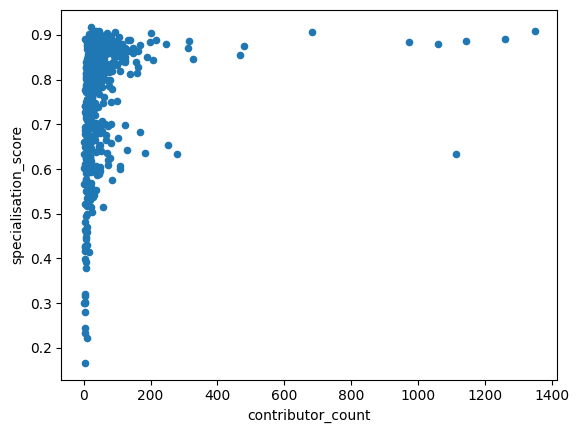

In [239]:
df_all_page_data.plot(x='contributor_count',y='specialisation_score',kind='scatter')

We see how the articles specialisation score reaches the 'average' as the number of contributors grows, approximating the distribution of gender of politicians represented in Wikidata.
But there are also some articles with a larger number of contributors, where the average specialisation score hovers around 0.6.

When we look at the 'content assessment in relation to the average specialisation, we find that the articles classified as *start* have a slightly lower score. 

specialisation_score    Axes(0.125,0.11;0.775x0.77)
dtype: object

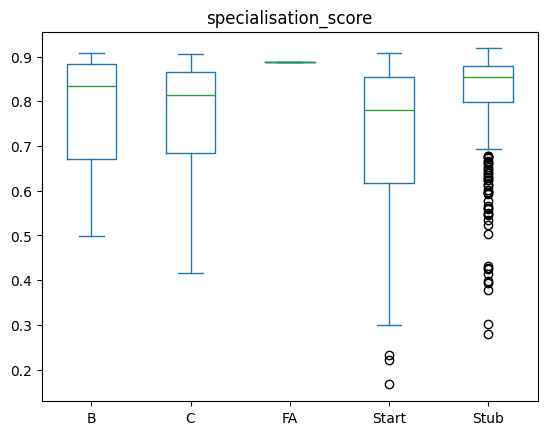

In [240]:
df_all_page_data.plot(by=['content_assessment'],column='specialisation_score',kind='box')


*Start*-classified articles are generally smaller (and are comparitively newer or with fewer editors), this might be an artifact of just approximating the number of contributors. Let's see how the number of editors varies between those categories:

contributor_count    Axes(0.125,0.11;0.775x0.77)
dtype: object

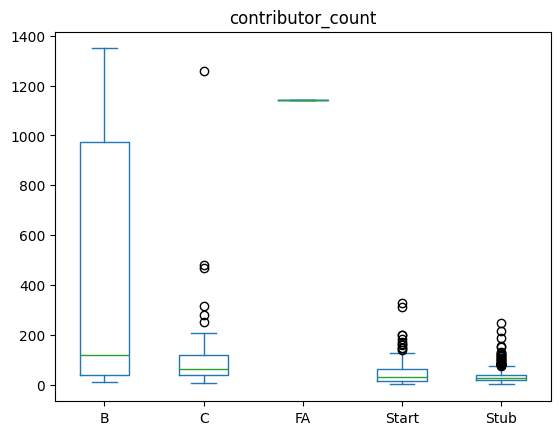

In [241]:
df_all_page_data.plot(by=['content_assessment'],column='contributor_count',kind='box')


For the *stub* articles, we see that they indeed have the smallest number of contributors - while the *start* articles have more editors and **still** have a lower specialisation score? Why could that be? 
One thing that could happen is that we are seeing the impact of targeted editing, e.g. in *Editathons* in which people contribute more fleshed-out articles (i.e. more than just *stubs*) on a given topic.
Was there maybe events for editing/adding missing pages for women in Kenya?

One thing we didn't take into account so far are bot accounts. What happens if we'd redo this whole work without bot accounts?

Let's remove them from our scoring too, similar how we removed the accounts with only a single edit.

**Note:** For now we are using a very lazy approach of just checking if `bot` or `Bot` appears as a substring in the name of an account – this is **not reliable** - there will accidental mismatches (c.f. the [Scunthorpe problem](https://en.wikipedia.org/wiki/Scunthorpe_problem)) and some bot accounts might not carry *bot* in the name. For a more rigorous check, you should check the Wikipedia user groups, as outlined in the introduction!

Despite those caveats, let's try this as a first step, to avoid querying the API some thousands of times:

In [242]:
df_editors['is_bot'] = df_editors.apply(lambda x: ("bot" in x.name) or ("Bot" in x.name), axis=1)
df_editors.head(20)

,male,female,total_pages,percent_male,is_bot
PrimeBOT,164.0,47.0,211.0,0.777251,False
Staryu,3.0,3.0,6.0,0.500000,False
Dodszi gera,1.0,0.0,1.0,1.000000,False
Dgp4004,17.0,2.0,19.0,0.894737,False
Jevansen,72.0,55.0,127.0,0.566929,False
Perspicax,70.0,14.0,84.0,0.833333,False
2A00:23C6:5408:2401:69EE:B427:1F08:D115,1.0,0.0,1.0,1.000000,False
Johnpacklambert,44.0,6.0,50.0,0.880000,False
Ser Amantio di Nicolao,392.0,103.0,495.0,0.791919,False
Chesiboi,71.0,12.0,83.0,0.855422,False


Now we can filter for accounts with edits to 2+ pages and not carrying *bot in the name*, redo our score calculation and plot the same curve:

<Axes: xlabel='contributor_count', ylabel='specialisation_score_no_bots'>

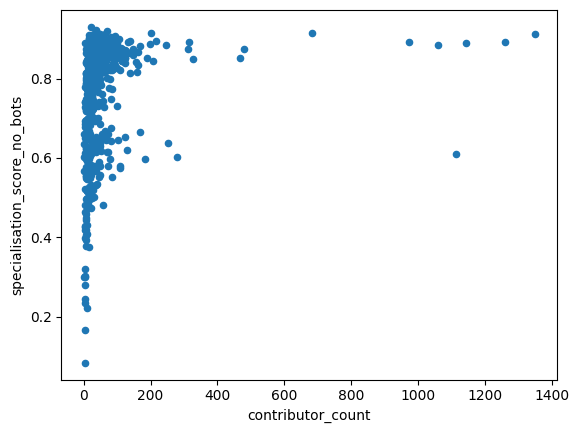

In [243]:
filtered_editors = df_editors.loc[(df_editors['total_pages']>=2) & (df_editors['is_bot'] != True)]


df_all_page_data['specialisation_score_no_bots'] = df_all_page_data.apply(
    calculate_specialisation_score,
    axis=1,
    args=[filtered_editors])

df_all_page_data.plot(x='contributor_count',y='specialisation_score_no_bots',kind='scatter')

This looks very similar to the picture we saw before!

Let's make a scatter plot to compare the per-page scores with or without bots:

<Axes: xlabel='specialisation_score', ylabel='specialisation_score_no_bots'>

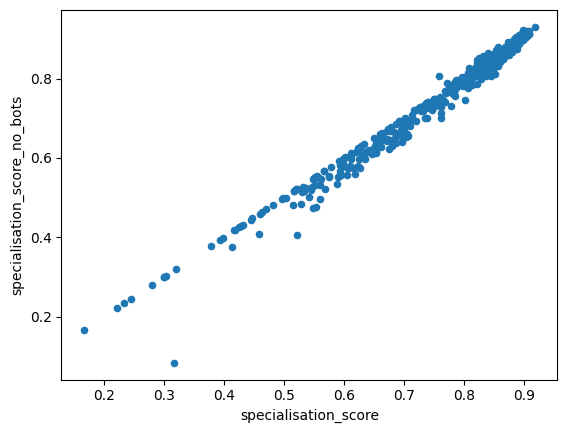

In [250]:
df_all_page_data.plot(x='specialisation_score',y='specialisation_score_no_bots',kind='scatter')

For some entries that seems to drop the calculated scores a bit, but looks quite similar overall, and we can see the same for the content assessment:

specialisation_score_no_bots    Axes(0.125,0.11;0.775x0.77)
dtype: object

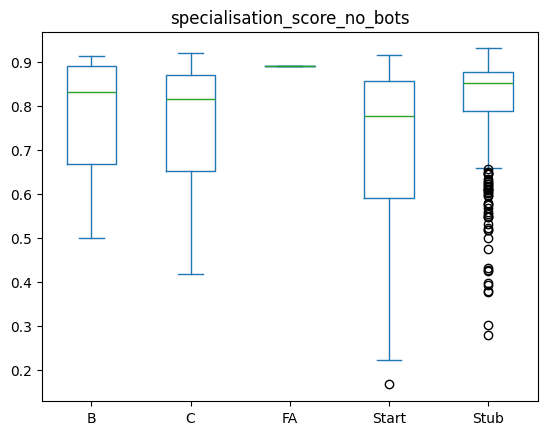

In [251]:
df_all_page_data.plot(by=['content_assessment'],column='specialisation_score_no_bots',kind='box')

This still approximates the same graph we saw before: *Start* articles are showing a less strong specialisation amongst editors.

## Specialisation depending on gender of biography

Now, let's look at the gender of the person a page is about, and see how the specialisation looks like there:

specialisation_score_no_bots    Axes(0.125,0.11;0.775x0.77)
dtype: object

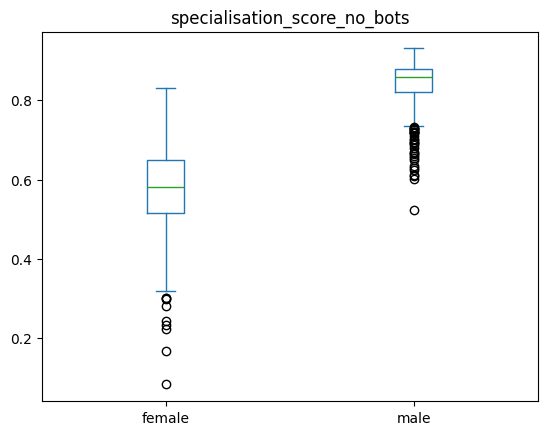

In [245]:
df_all_page_data[df_all_page_data['contributor_count'] <2000 ].plot(by=['gender'],column='specialisation_score_no_bots',kind='box')

This shows us that biographies about women show a lot less specialisation - i.e. are by a mix of contributors who contribute to male & female biographies.

In contrast, the male biographies are mostly dominated by contributors that mostly contribute to biographies of men.

Let's double check if there is a clear bias in numbers of contributors between the male & female articles?

contributor_count    Axes(0.125,0.11;0.775x0.77)
dtype: object

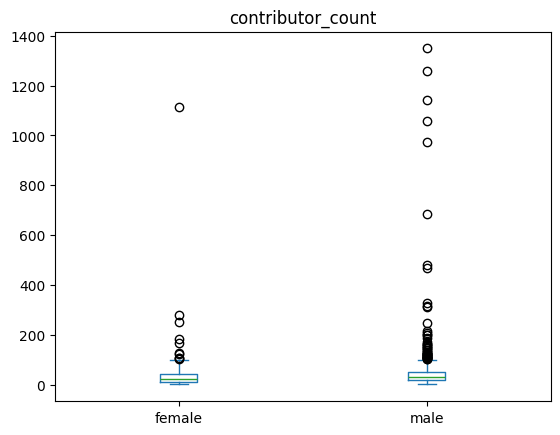

In [246]:
df_all_page_data.plot(by=['gender'],column='contributor_count',kind='box')

For the median, that does not seem to be the case, despite having some strong outliers with much larger contributor numbes for men.

# Gender, specialisation and quality

Lastly, let's now combine it all and look at a per-gender breakdown and see if there are systematic differences. First for all pages, and then removing pages that had fewer than 200 editors, to remove large outliers 

specialisation_score_no_bots    Axes(0.125,0.11;0.775x0.77)
dtype: object

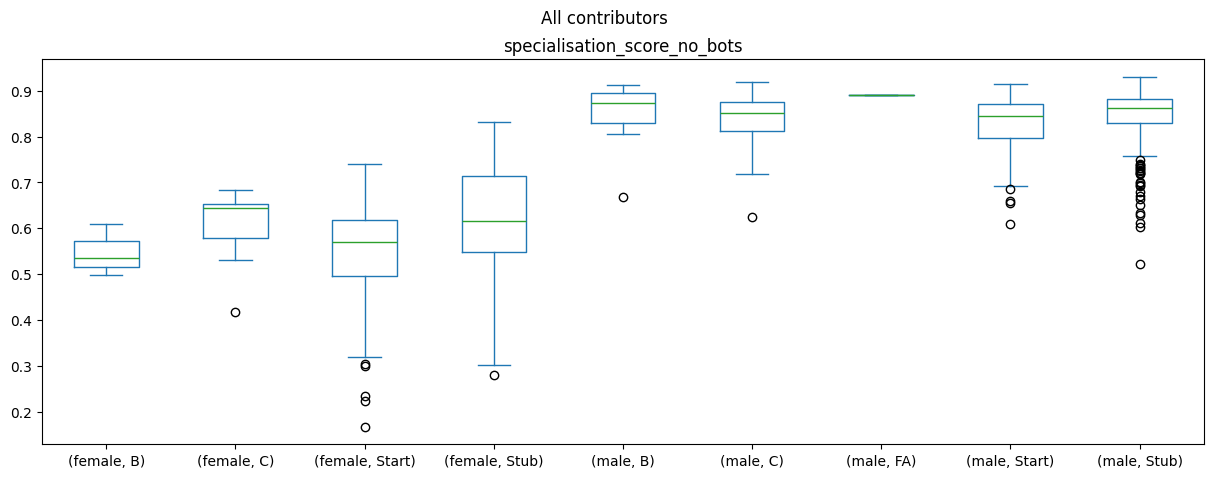

In [258]:
df_all_page_data.plot(by=['gender','content_assessment'],column='specialisation_score_no_bots',kind='box',figsize=(15,5),title='All contributors') # WITHOUT filter for articles with very large numbers of editors

specialisation_score_no_bots    Axes(0.125,0.11;0.775x0.77)
dtype: object

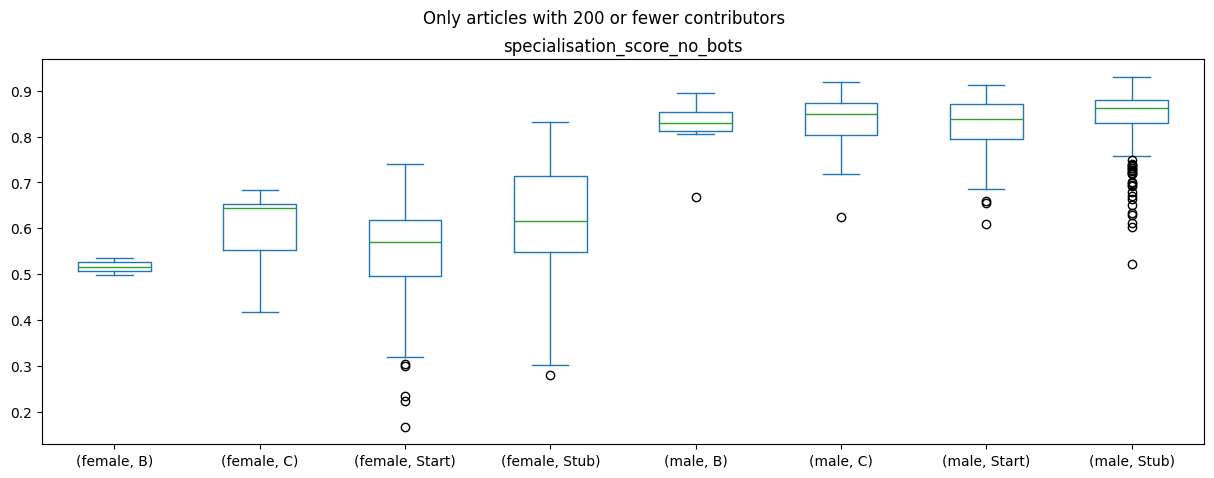

In [259]:
df_all_page_data[df_all_page_data['contributor_count'] <200 ].plot(by=['gender','content_assessment'],column='specialisation_score_no_bots',kind='box',figsize=(15,5),title="Only articles with 200 or fewer contributors") # filter for articles with very large numbers of editors

The difference between the biography gender and the specialisation score generally holds across all article content ratings, but there doesn't seem to be a strong impact or difference between the article ratings and the specialisation score.

But, maybe there is one between the article quality and number of editors? Let's make a plot for that too:

contributor_count    Axes(0.125,0.11;0.775x0.77)
dtype: object

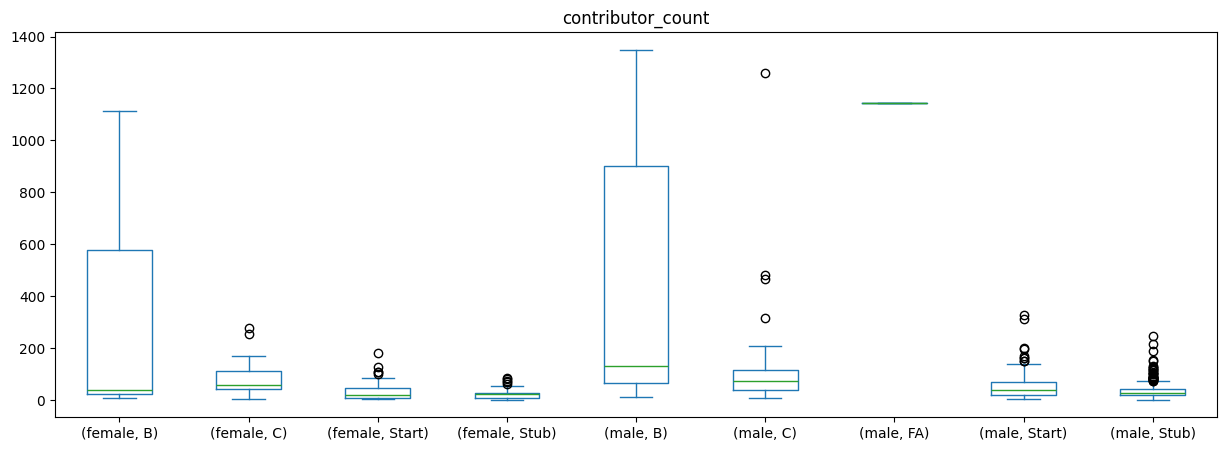

In [260]:
df_all_page_data.plot(by=['gender','content_assessment'],column='contributor_count',kind='box',figsize=(15,5)) # WITHOUT filter for articles with very large numbers of editors

This seems to indeed be roughly the case: The 'better' an article, the more people have contributed to it!